<a href="https://colab.research.google.com/github/LeonardoMBastos/Codes-for-PhD-graphs/blob/main/DockAnalyzer_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 3D SCATTER PLOT
# X = Affinity
# Y = RMSD
# Z = Score
# Color = Contacts
# ============================================================

# ------------------------------------------------------------
# 1. Install packages
# ------------------------------------------------------------

packages <- c(
  "readr",
  "dplyr",
  "janitor",
  "plotly",
  "htmlwidgets"
)

new_packages <- packages[!(packages %in% installed.packages()[, "Package"])]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}




Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘snakecase’, ‘crosstalk’




In [2]:
# ------------------------------------------------------------
# 2. Load packages
# ------------------------------------------------------------

library(readr)
library(dplyr)
library(janitor)
library(plotly)
library(htmlwidgets)





Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


Loading required package: ggplot2


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




In [3]:
# ------------------------------------------------------------
# 3. Find uploaded CSV file
# ------------------------------------------------------------
# Upload your CSV using the Google Colab "Files" panel.
# The code automatically detects the CSV file.

csv_files <- list.files(
  path = ".",
  pattern = "\\.csv$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (length(csv_files) == 0) {
  stop("No CSV file found. Upload the CSV file to Google Colab first.")
}

# If there is more than one CSV, the first one will be used
file_path <- csv_files[1]

cat("File loaded:", file_path, "\n")


# ------------------------------------------------------------
# 4. Read complete CSV
# ------------------------------------------------------------

data_raw <- read_csv(
  file_path,
  show_col_types = FALSE
)




File loaded: ./02. Results DockAnalyzer - DZP.csv 


In [ ]:
# ------------------------------------------------------------
# 5. Standardize column names
# ------------------------------------------------------------
# Examples:
# "Affinity" -> affinity
# "RMSD" -> rmsd
# "Score" -> score
# "Contacts" -> contacts

data_raw <- data_raw %>%
  clean_names()


# Correct possible typo RSMD -> RMSD
if ("rsmd" %in% names(data_raw) &&
    !"rmsd" %in% names(data_raw)) {

  data_raw <- data_raw %>%
    rename(rmsd = rsmd)
}


# ------------------------------------------------------------
# 6. Check required columns
# ------------------------------------------------------------

required_columns <- c(
  "affinity",
  "rmsd",
  "score",
  "contacts"
)

missing_columns <- setdiff(
  required_columns,
  names(data_raw)
)

if (length(missing_columns) > 0) {

  stop(
    paste(
      "Missing columns:",
      paste(missing_columns, collapse = ", ")
    )
  )
}


# ------------------------------------------------------------
# 7. Extract only columns used in the graph
# ------------------------------------------------------------

data_plot <- data_raw %>%
  select(
    affinity,
    rmsd,
    score,
    contacts
  ) %>%
  mutate(
    affinity = as.numeric(affinity),
    rmsd     = as.numeric(rmsd),
    score    = as.numeric(score),
    contacts = as.numeric(contacts)
  ) %>%
  filter(
    complete.cases(.)
  )


# Show extracted data
head(data_plot)




affinity,rmsd,score,contacts
<dbl>,<dbl>,<dbl>,<dbl>
-9.252,1.314,148528,59
-8.509,3.823,82281,52
-8.453,3.781,131625,78
-7.871,4.476,94263,44
-7.727,4.412,8907,54
-9.260,1.335,147661,60


In [ ]:
cat("Número de linhas:", nrow(data_plot), "\n\n")

cat("Affinity:\n")
print(range(data_plot$affinity, na.rm = TRUE))

cat("\nRMSD:\n")
print(range(data_plot$rmsd, na.rm = TRUE))

cat("\nScore:\n")
print(range(data_plot$score, na.rm = TRUE))

cat("\nContacts:\n")
print(range(data_plot$contacts, na.rm = TRUE))

cat("\nPrimeiras linhas:\n")
print(head(data_plot))

Número de linhas: 141 

Affinity:
[1] -9.283 -6.542

RMSD:
[1] 1.314 5.268

Score:
[1]   6784 152073

Contacts:
[1] 37 81

Primeiras linhas:
# A tibble: 6 × 4
  affinity  rmsd  score contacts
     <dbl> <dbl>  <dbl>    <dbl>
1    -9.25  1.31 148528       59
2    -8.51  3.82  82281       52
3    -8.45  3.78 131625       78
4    -7.87  4.48  94263       44
5    -7.73  4.41   8907       54
6    -9.26  1.34 147661       60


In [ ]:
# ------------------------------------------------------------
# 7.5 Fit prediction surface model
# ------------------------------------------------------------

# Polynomial regression model:
# score = f(affinity, rmsd)
surface_model <- lm(
  score ~ affinity + rmsd + I(affinity^2) + I(rmsd^2) + affinity:rmsd,
  data = data_plot
)

# Create prediction grid
x_seq <- seq(
  min(data_plot$affinity, na.rm = TRUE),
  max(data_plot$affinity, na.rm = TRUE),
  length.out = 50
)

y_seq <- seq(
  min(data_plot$rmsd, na.rm = TRUE),
  max(data_plot$rmsd, na.rm = TRUE),
  length.out = 50
)

grid_df <- expand.grid(
  affinity = x_seq,
  rmsd = y_seq
)

# Predict score values over the grid
grid_df$score_pred <- predict(surface_model, newdata = grid_df)

# Convert predictions to matrix for plotly surface
z_matrix <- matrix(
  grid_df$score_pred,
  nrow = length(y_seq),
  ncol = length(x_seq),
  byrow = FALSE
)

In [ ]:
# ------------------------------------------------------------
# 8. Create interactive 3D scatter plot + prediction surface
# ------------------------------------------------------------

fig <- plot_ly()

# Add prediction surface
fig <- fig %>%
  add_surface(
    x = x_seq,
    y = y_seq,
    z = z_matrix,
    opacity = 0.45,
    showscale = FALSE,
    name = "Prediction surface",
    hoverinfo = "skip"
  )

# Add observed data points
fig <- fig %>%
  add_trace(
    data = data_plot,
    x = ~affinity,
    y = ~rmsd,
    z = ~score,
    type = "scatter3d",
    mode = "markers",
    marker = list(
      size = 5,
      opacity = 0.80,
      color = data_plot$contacts,
      colorscale = "Viridis",
      showscale = TRUE,
      colorbar = list(title = "Contacts"),
      line = list(width = 0)
    ),
    text = ~paste(
      "<b>Affinity:</b>", round(affinity, 3),
      "<br><b>RMSD:</b>", round(rmsd, 3),
      "<br><b>Score:</b>", round(score, 2),
      "<br><b>Contacts:</b>", contacts
    ),
    hoverinfo = "text",
    name = "Observed points"
  )


# ------------------------------------------------------------
# 9. Graph layout
# ------------------------------------------------------------

fig <- fig %>%
  layout(
    title = list(
      text = "Affinity × RMSD × Score with Prediction Surface"
    ),
    scene = list(
      xaxis = list(
        title = "Affinity (kcal/mol)",
        zeroline = FALSE
      ),
      yaxis = list(
        title = "RMSD (Å)",
        zeroline = FALSE
      ),
      zaxis = list(
        title = "Score",
        autorange = TRUE,
        zeroline = FALSE
      ),
      camera = list(
        eye = list(
          x = 1.5,
          y = 1.5,
          z = 1.2
        )
      )
    )
  )



# ------------------------------------------------------------
# 10. Display / save graph
# ------------------------------------------------------------

htmlwidgets::saveWidget(
  fig,
  "grafico_3D.html",
  selfcontained = TRUE
)

cat("Graph saved as: grafico_3D.html\n")

Graph saved as: grafico_3D.html


File loaded: ./02. Results DockAnalyzer - DZP.csv 

Number of observations: 141 

PEARSON CORRELATION
Variables: affinity vs rmsd 
N: 141 
Pearson r: 0.7014 
95% CI: [0.6063, 0.7766] 
p-value: < 0.001 

LINEAR REGRESSION
Intercept: 12.8395 
Slope: 1.1332 
R²: 0.4919 
Adjusted R²: 0.4882 
Slope p-value: < 0.001 

Regression equation:
rmsd = 12.8395 + 1.1332 × affinity 

COMPLETE REGRESSION SUMMARY

Call:
lm(formula = model_formula, data = data_plot)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6349 -0.3432  0.3470  0.5880  0.6957 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 12.83950    0.78574   16.34   <2e-16 ***
affinity     1.13318    0.09769   11.60   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7588 on 139 degrees of freedom
Multiple R-squared:  0.4919,	Adjusted R-squared:  0.4882 
F-statistic: 134.6 on 1 and 139 DF,  p-value: < 2.2e-16



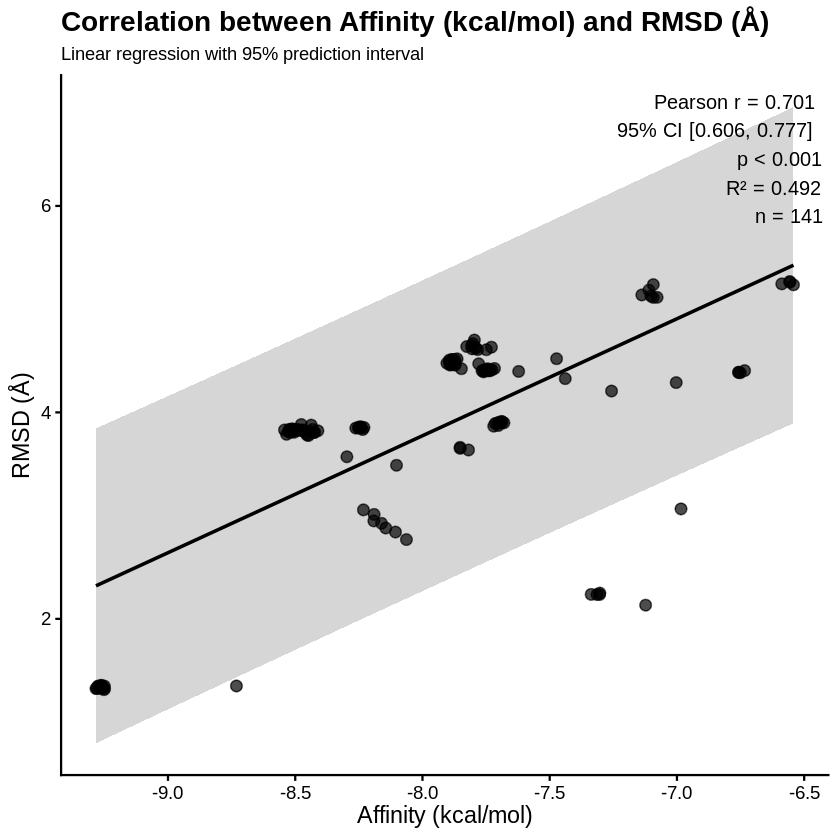

In [4]:
# ============================================================
# CORRELATION PLOT WITH LINEAR TREND
# AND 95% PREDICTION INTERVAL
#
# Initial analysis:
# X = Affinity
# Y = RMSD
# ============================================================


# ------------------------------------------------------------
# 1. Install required packages
# ------------------------------------------------------------

packages <- c(
  "readr",
  "dplyr",
  "janitor",
  "ggplot2"
)

new_packages <- packages[
  !(packages %in% installed.packages()[, "Package"])
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}


# ------------------------------------------------------------
# 2. Load packages
# ------------------------------------------------------------

library(readr)
library(dplyr)
library(janitor)
library(ggplot2)


# ============================================================
# 3. VARIABLES TO ANALYZE
# ============================================================
#
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# CHANGE ONLY THIS SECTION TO TEST OTHER VARIABLES
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

X_VAR <- "affinity"
Y_VAR <- "rmsd"

X_LABEL <- "Affinity (kcal/mol)"
Y_LABEL <- "RMSD (Å)"

# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# Example for Affinity × Score:
#
# X_VAR <- "affinity"
# Y_VAR <- "score"
#
# X_LABEL <- "Affinity (kcal/mol)"
# Y_LABEL <- "Score"
#
# Example for RMSD × Score:
#
# X_VAR <- "rmsd"
# Y_VAR <- "score"
#
# X_LABEL <- "RMSD (Å)"
# Y_LABEL <- "Score"
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


# ------------------------------------------------------------
# 4. Find uploaded CSV file
# ------------------------------------------------------------

csv_files <- list.files(
  path = ".",
  pattern = "\\.csv$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (length(csv_files) == 0) {
  stop("No CSV file found. Upload the CSV file first.")
}

file_path <- csv_files[1]

cat("File loaded:", file_path, "\n")


# ------------------------------------------------------------
# 5. Read complete CSV
# ------------------------------------------------------------

data_raw <- read_csv(
  file_path,
  show_col_types = FALSE
)


# ------------------------------------------------------------
# 6. Standardize column names
# ------------------------------------------------------------

data_raw <- data_raw %>%
  clean_names()


# Correct possible typo: RSMD -> RMSD
if (
  "rsmd" %in% names(data_raw) &&
  !"rmsd" %in% names(data_raw)
) {
  data_raw <- data_raw %>%
    rename(rmsd = rsmd)
}


# ------------------------------------------------------------
# 7. Check selected variables
# ------------------------------------------------------------

required_columns <- c(X_VAR, Y_VAR)

missing_columns <- setdiff(
  required_columns,
  names(data_raw)
)

if (length(missing_columns) > 0) {

  cat("\nAvailable columns:\n")
  print(names(data_raw))

  stop(
    paste(
      "Missing columns:",
      paste(missing_columns, collapse = ", ")
    )
  )
}


# ------------------------------------------------------------
# 8. Extract variables and remove missing values
# ------------------------------------------------------------

data_plot <- data_raw %>%
  select(
    all_of(c(X_VAR, Y_VAR))
  ) %>%
  mutate(
    across(
      everything(),
      as.numeric
    )
  ) %>%
  filter(
    complete.cases(.)
  )


cat("\nNumber of observations:", nrow(data_plot), "\n")


# ------------------------------------------------------------
# 9. Pearson correlation
# ------------------------------------------------------------

correlation <- cor.test(
  data_plot[[X_VAR]],
  data_plot[[Y_VAR]],
  method = "pearson",
  conf.level = 0.95
)


# Extract correlation statistics
r_value <- unname(correlation$estimate)

p_value <- correlation$p.value

r_ci_low <- correlation$conf.int[1]
r_ci_high <- correlation$conf.int[2]

n_value <- nrow(data_plot)


# ------------------------------------------------------------
# 10. Linear regression
# ------------------------------------------------------------

model_formula <- reformulate(
  X_VAR,
  response = Y_VAR
)

model <- lm(
  model_formula,
  data = data_plot
)

model_summary <- summary(model)


# Extract regression statistics
intercept <- coef(model)[1]
slope <- coef(model)[2]

r_squared <- model_summary$r.squared
adjusted_r_squared <- model_summary$adj.r.squared

slope_p <- model_summary$coefficients[2, 4]


# ------------------------------------------------------------
# 11. Create prediction interval
# ------------------------------------------------------------

x_sequence <- seq(
  min(data_plot[[X_VAR]], na.rm = TRUE),
  max(data_plot[[X_VAR]], na.rm = TRUE),
  length.out = 300
)


prediction_data <- data.frame(x_sequence)

names(prediction_data) <- X_VAR


predictions <- predict(
  model,
  newdata = prediction_data,
  interval = "prediction",
  level = 0.95
)


prediction_data$fit <- predictions[, "fit"]
prediction_data$lwr <- predictions[, "lwr"]
prediction_data$upr <- predictions[, "upr"]


# ------------------------------------------------------------
# 12. Format statistical information
# ------------------------------------------------------------

format_p <- function(p) {

  if (p < 0.001) {
    return("p < 0.001")
  }

  paste0(
    "p = ",
    formatC(
      p,
      format = "f",
      digits = 3
    )
  )
}


statistics_label <- paste0(
  "Pearson r = ",
  sprintf("%.3f", r_value),

  "\n95% CI [",
  sprintf("%.3f", r_ci_low),
  ", ",
  sprintf("%.3f", r_ci_high),
  "]",

  "\n",
  format_p(p_value),

  "\nR² = ",
  sprintf("%.3f", r_squared),

  "\nn = ",
  n_value
)


# ------------------------------------------------------------
# 13. Create correlation plot
# ------------------------------------------------------------

fig <- ggplot(
  data_plot,
  aes(
    x = .data[[X_VAR]],
    y = .data[[Y_VAR]]
  )
) +

  # 95% prediction interval
  geom_ribbon(
    data = prediction_data,
    aes(
      x = .data[[X_VAR]],
      ymin = lwr,
      ymax = upr
    ),
    inherit.aes = FALSE,
    alpha = 0.20
  ) +

  # Linear regression line
  geom_line(
    data = prediction_data,
    aes(
      x = .data[[X_VAR]],
      y = fit
    ),
    inherit.aes = FALSE,
    linewidth = 1
  ) +

  # Observed values
  geom_point(
    size = 2.8,
    alpha = 0.70
  ) +

  # Statistical information
  annotate(
    "text",
    x = Inf,
    y = Inf,
    label = statistics_label,
    hjust = 1.08,
    vjust = 1.15,
    size = 4.2
  ) +

  labs(
    title = paste0(
      "Correlation between ",
      X_LABEL,
      " and ",
      Y_LABEL
    ),
    subtitle = "Linear regression with 95% prediction interval",
    x = X_LABEL,
    y = Y_LABEL
  ) +

  theme_classic(base_size = 14) +

  theme(
    plot.title = element_text(
      face = "bold"
    ),

    plot.subtitle = element_text(
      size = 11
    )
  )


# ------------------------------------------------------------
# 14. Display graph
# ------------------------------------------------------------

print(fig)


# ------------------------------------------------------------
# 15. Statistical results
# ------------------------------------------------------------

cat("\n")
cat("============================================\n")
cat("PEARSON CORRELATION\n")
cat("============================================\n")

cat(
  "Variables:",
  X_VAR,
  "vs",
  Y_VAR,
  "\n"
)

cat(
  "N:",
  n_value,
  "\n"
)

cat(
  "Pearson r:",
  round(r_value, 4),
  "\n"
)

cat(
  "95% CI:",
  paste0(
    "[",
    round(r_ci_low, 4),
    ", ",
    round(r_ci_high, 4),
    "]"
  ),
  "\n"
)

cat(
  "p-value:",
  format.pval(
    p_value,
    digits = 4,
    eps = 0.001
  ),
  "\n"
)


cat("\n")
cat("============================================\n")
cat("LINEAR REGRESSION\n")
cat("============================================\n")

cat(
  "Intercept:",
  round(intercept, 4),
  "\n"
)

cat(
  "Slope:",
  round(slope, 4),
  "\n"
)

cat(
  "R²:",
  round(r_squared, 4),
  "\n"
)

cat(
  "Adjusted R²:",
  round(adjusted_r_squared, 4),
  "\n"
)

cat(
  "Slope p-value:",
  format.pval(
    slope_p,
    digits = 4,
    eps = 0.001
  ),
  "\n"
)

cat("\nRegression equation:\n")

cat(
  Y_VAR,
  "=",
  round(intercept, 4),
  ifelse(slope >= 0, "+", "-"),
  abs(round(slope, 4)),
  "×",
  X_VAR,
  "\n"
)


# ------------------------------------------------------------
# 16. Complete model summary
# ------------------------------------------------------------

cat("\n")
cat("============================================\n")
cat("COMPLETE REGRESSION SUMMARY\n")
cat("============================================\n")

print(
  summary(model)
)

File loaded: ./02. Results DockAnalyzer - DZP.csv 

Number of observations: 141 

PEARSON CORRELATION: SCORE × RMSD
Variables: Score vs RMSD
N: 141 
Pearson r: -0.4155 
95% CI: [-0.5435, -0.2687] 
p-value: < 0.001 

LINEAR REGRESSION: RMSD ~ SCORE
Intercept: 4.7708 
Slope: -1.1e-05 
R²: 0.1727 
Adjusted R²: 0.1667 
Slope p-value: < 0.001 

Regression equation:
RMSD = 4.7708 - 1.1e-05 × Score

COMPLETE REGRESSION SUMMARY

Call:
lm(formula = model_formula, data = data_plot)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4560 -0.2621  0.2972  0.6564  1.8638 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.771e+00  2.055e-01  23.218  < 2e-16 ***
score       -1.129e-05  2.096e-06  -5.386 2.99e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9682 on 139 degrees of freedom
Multiple R-squared:  0.1727,	Adjusted R-squared:  0.1667 
F-statistic: 29.01 on 1 and 139 DF,  p-value: 2.993e-07



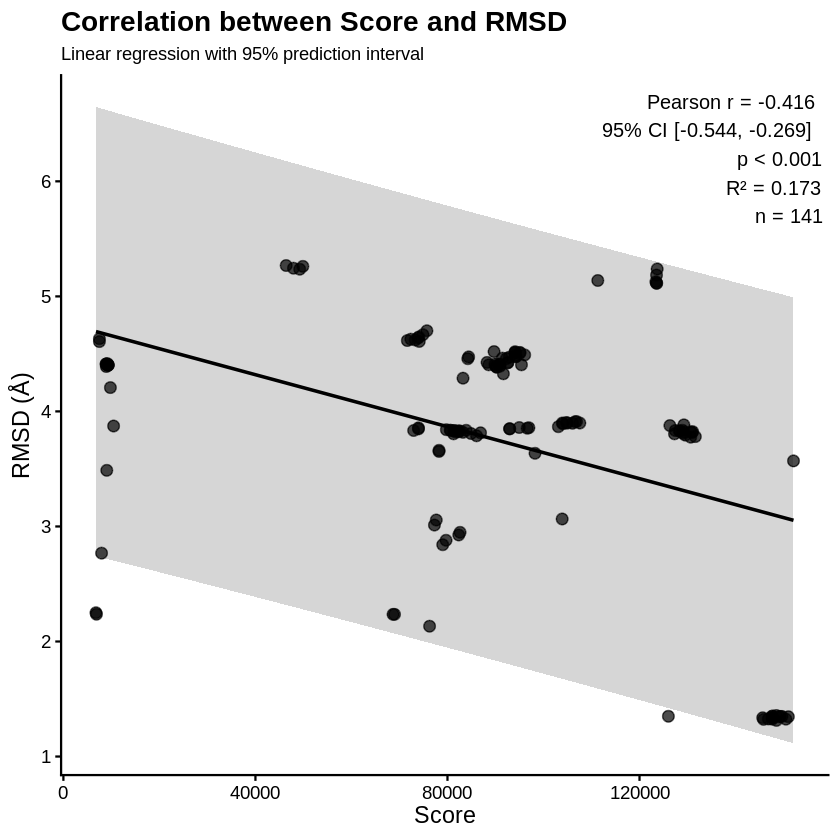

In [5]:
# ============================================================
# CORRELATION: SCORE × RMSD
# LINEAR REGRESSION WITH 95% PREDICTION INTERVAL
# ============================================================


# ------------------------------------------------------------
# 1. Install required packages
# ------------------------------------------------------------

packages <- c(
  "readr",
  "dplyr",
  "janitor",
  "ggplot2"
)

new_packages <- packages[
  !(packages %in% installed.packages()[, "Package"])
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}


# ------------------------------------------------------------
# 2. Load packages
# ------------------------------------------------------------

library(readr)
library(dplyr)
library(janitor)
library(ggplot2)


# ============================================================
# 3. VARIABLES TO ANALYZE
# ============================================================
#
# CURRENT ANALYSIS:
# X = Score
# Y = RMSD
#
# To perform another correlation in the future,
# change only these four lines.
# ============================================================

X_VAR <- "score"
Y_VAR <- "rmsd"

X_LABEL <- "Score"
Y_LABEL <- "RMSD (Å)"


# ------------------------------------------------------------
# 4. Find uploaded CSV file
# ------------------------------------------------------------

csv_files <- list.files(
  path = ".",
  pattern = "\\.csv$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (length(csv_files) == 0) {
  stop("No CSV file found. Upload the CSV file first.")
}

file_path <- csv_files[1]

cat("File loaded:", file_path, "\n")


# ------------------------------------------------------------
# 5. Read complete CSV
# ------------------------------------------------------------

data_raw <- read_csv(
  file_path,
  show_col_types = FALSE
)


# ------------------------------------------------------------
# 6. Standardize column names
# ------------------------------------------------------------

data_raw <- data_raw %>%
  clean_names()


# Correct possible typo: RSMD -> RMSD
if (
  "rsmd" %in% names(data_raw) &&
  !"rmsd" %in% names(data_raw)
) {

  data_raw <- data_raw %>%
    rename(rmsd = rsmd)
}


# ------------------------------------------------------------
# 7. Check selected variables
# ------------------------------------------------------------

required_columns <- c(
  X_VAR,
  Y_VAR
)

missing_columns <- setdiff(
  required_columns,
  names(data_raw)
)

if (length(missing_columns) > 0) {

  cat("\nAvailable columns:\n")
  print(names(data_raw))

  stop(
    paste(
      "Missing columns:",
      paste(missing_columns, collapse = ", ")
    )
  )
}


# ------------------------------------------------------------
# 8. Extract Score and RMSD
# ------------------------------------------------------------

data_plot <- data_raw %>%
  select(
    all_of(c(X_VAR, Y_VAR))
  ) %>%
  mutate(
    across(
      everything(),
      as.numeric
    )
  ) %>%
  filter(
    complete.cases(.)
  )


cat(
  "\nNumber of observations:",
  nrow(data_plot),
  "\n"
)


# ------------------------------------------------------------
# 9. Pearson correlation
# ------------------------------------------------------------

correlation <- cor.test(
  data_plot[[X_VAR]],
  data_plot[[Y_VAR]],
  method = "pearson",
  conf.level = 0.95
)


# Extract correlation statistics

r_value <- unname(
  correlation$estimate
)

p_value <- correlation$p.value

r_ci_low <- correlation$conf.int[1]

r_ci_high <- correlation$conf.int[2]

n_value <- nrow(data_plot)


# ------------------------------------------------------------
# 10. Linear regression
# ------------------------------------------------------------

model_formula <- reformulate(
  X_VAR,
  response = Y_VAR
)

model <- lm(
  model_formula,
  data = data_plot
)

model_summary <- summary(model)


# Extract regression statistics

intercept <- coef(model)[1]

slope <- coef(model)[2]

r_squared <- model_summary$r.squared

adjusted_r_squared <- model_summary$adj.r.squared

slope_p <- model_summary$coefficients[2, 4]


# ------------------------------------------------------------
# 11. Create 95% prediction interval
# ------------------------------------------------------------

x_sequence <- seq(
  min(
    data_plot[[X_VAR]],
    na.rm = TRUE
  ),
  max(
    data_plot[[X_VAR]],
    na.rm = TRUE
  ),
  length.out = 300
)


prediction_data <- data.frame(
  x_sequence
)

names(prediction_data) <- X_VAR


predictions <- predict(
  model,
  newdata = prediction_data,
  interval = "prediction",
  level = 0.95
)


prediction_data$fit <- predictions[, "fit"]

prediction_data$lwr <- predictions[, "lwr"]

prediction_data$upr <- predictions[, "upr"]


# ------------------------------------------------------------
# 12. Format statistical information
# ------------------------------------------------------------

format_p <- function(p) {

  if (p < 0.001) {
    return("p < 0.001")
  }

  paste0(
    "p = ",
    formatC(
      p,
      format = "f",
      digits = 3
    )
  )
}


statistics_label <- paste0(

  "Pearson r = ",
  sprintf(
    "%.3f",
    r_value
  ),

  "\n95% CI [",
  sprintf(
    "%.3f",
    r_ci_low
  ),
  ", ",
  sprintf(
    "%.3f",
    r_ci_high
  ),
  "]",

  "\n",
  format_p(
    p_value
  ),

  "\nR² = ",
  sprintf(
    "%.3f",
    r_squared
  ),

  "\nn = ",
  n_value
)


# ------------------------------------------------------------
# 13. Create Score × RMSD correlation plot
# ------------------------------------------------------------

fig <- ggplot(

  data_plot,

  aes(
    x = .data[[X_VAR]],
    y = .data[[Y_VAR]]
  )

) +

  # 95% prediction interval
  geom_ribbon(

    data = prediction_data,

    aes(
      x = .data[[X_VAR]],
      ymin = lwr,
      ymax = upr
    ),

    inherit.aes = FALSE,
    alpha = 0.20
  ) +

  # Linear regression trend
  geom_line(

    data = prediction_data,

    aes(
      x = .data[[X_VAR]],
      y = fit
    ),

    inherit.aes = FALSE,
    linewidth = 1
  ) +

  # Observed points
  geom_point(
    size = 2.8,
    alpha = 0.70
  ) +

  # Statistical results displayed inside graph
  annotate(
    "text",
    x = Inf,
    y = Inf,
    label = statistics_label,
    hjust = 1.08,
    vjust = 1.15,
    size = 4.2
  ) +

  labs(

    title = "Correlation between Score and RMSD",

    subtitle = "Linear regression with 95% prediction interval",

    x = "Score",

    y = "RMSD (Å)"
  ) +

  theme_classic(
    base_size = 14
  ) +

  theme(

    plot.title = element_text(
      face = "bold"
    ),

    plot.subtitle = element_text(
      size = 11
    )
  )


# ------------------------------------------------------------
# 14. Display graph
# ------------------------------------------------------------

print(fig)


# ------------------------------------------------------------
# 15. Pearson correlation results
# ------------------------------------------------------------

cat("\n")

cat(
  "============================================\n"
)

cat(
  "PEARSON CORRELATION: SCORE × RMSD\n"
)

cat(
  "============================================\n"
)


cat(
  "Variables: Score vs RMSD\n"
)


cat(
  "N:",
  n_value,
  "\n"
)


cat(
  "Pearson r:",
  round(
    r_value,
    4
  ),
  "\n"
)


cat(
  "95% CI:",
  paste0(
    "[",
    round(
      r_ci_low,
      4
    ),
    ", ",
    round(
      r_ci_high,
      4
    ),
    "]"
  ),
  "\n"
)


cat(
  "p-value:",
  format.pval(
    p_value,
    digits = 4,
    eps = 0.001
  ),
  "\n"
)


# ------------------------------------------------------------
# 16. Linear regression results
# ------------------------------------------------------------

cat("\n")

cat(
  "============================================\n"
)

cat(
  "LINEAR REGRESSION: RMSD ~ SCORE\n"
)

cat(
  "============================================\n"
)


cat(
  "Intercept:",
  round(
    intercept,
    4
  ),
  "\n"
)


cat(
  "Slope:",
  round(
    slope,
    6
  ),
  "\n"
)


cat(
  "R²:",
  round(
    r_squared,
    4
  ),
  "\n"
)


cat(
  "Adjusted R²:",
  round(
    adjusted_r_squared,
    4
  ),
  "\n"
)


cat(
  "Slope p-value:",
  format.pval(
    slope_p,
    digits = 4,
    eps = 0.001
  ),
  "\n"
)


# ------------------------------------------------------------
# 17. Regression equation
# ------------------------------------------------------------

cat("\nRegression equation:\n")

cat(
  "RMSD =",
  round(
    intercept,
    4
  ),

  ifelse(
    slope >= 0,
    "+",
    "-"
  ),

  abs(
    round(
      slope,
      6
    )
  ),

  "× Score\n"
)


# ------------------------------------------------------------
# 18. Complete regression summary
# ------------------------------------------------------------

cat("\n")

cat(
  "============================================\n"
)

cat(
  "COMPLETE REGRESSION SUMMARY\n"
)

cat(
  "============================================\n"
)

print(
  summary(model)
)


File loaded: ./02. Results DockAnalyzer - DZP.csv 

Number of observations: 141 

PEARSON CORRELATION: SCORE × AFFINITY
Variables: Score vs Affinity
N: 141 
Pearson r: -0.5338 
95% CI: [-0.6424, -0.4041] 
p-value: < 0.001 

LINEAR REGRESSION: AFFINITY ~ SCORE
Intercept: -7.2093 
Slope: -9e-06 
R²: 0.2849 
Adjusted R²: 0.2798 
Slope p-value: < 0.001 

Regression equation:
Affinity = -7.2093 - 9e-06 × Score

COMPLETE REGRESSION SUMMARY

Call:
lm(formula = model_formula, data = data_plot)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.81158 -0.46475 -0.06208  0.28328  1.27063 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -7.209e+00  1.182e-01 -60.973  < 2e-16 ***
score       -8.977e-06  1.206e-06  -7.442  9.4e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5571 on 139 degrees of freedom
Multiple R-squared:  0.2849,	Adjusted R-squared:  0.2798 
F-statistic: 55.38 on 1 and 139 DF,  p-va

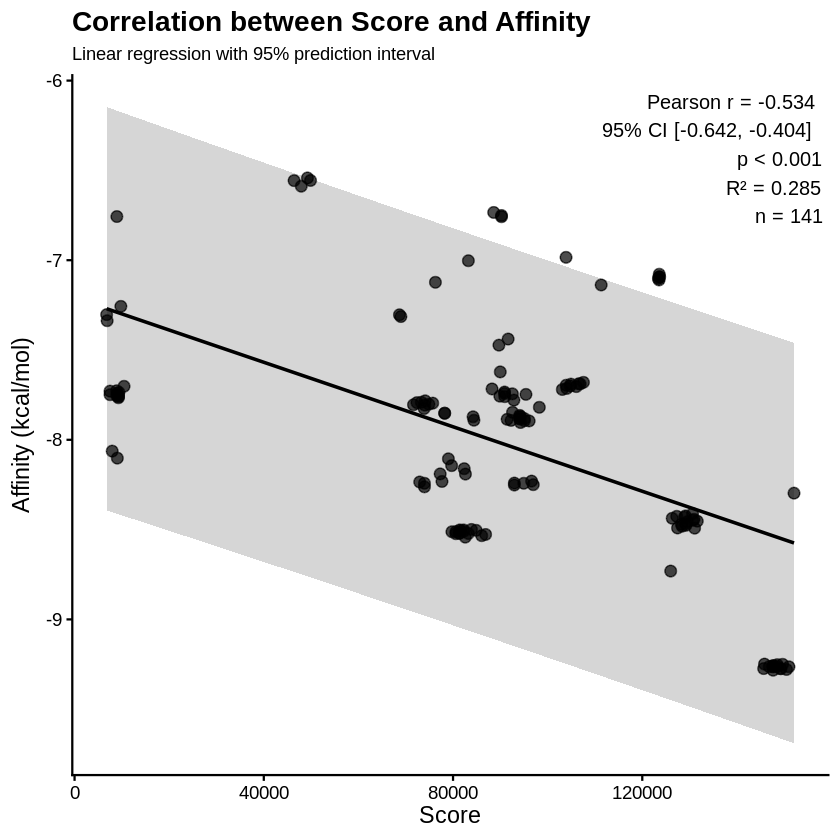

In [6]:
# ============================================================
# CORRELATION: SCORE × AFFINITY
# LINEAR REGRESSION WITH 95% PREDICTION INTERVAL
# ============================================================


# ------------------------------------------------------------
# 1. Install required packages
# ------------------------------------------------------------

packages <- c(
  "readr",
  "dplyr",
  "janitor",
  "ggplot2"
)

new_packages <- packages[
  !(packages %in% installed.packages()[, "Package"])
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}


# ------------------------------------------------------------
# 2. Load packages
# ------------------------------------------------------------

library(readr)
library(dplyr)
library(janitor)
library(ggplot2)


# ============================================================
# 3. VARIABLES TO ANALYZE
# ============================================================
#
# CURRENT ANALYSIS:
# X = Score
# Y = Affinity
#
# To perform another correlation in the future,
# change only these four lines.
# ============================================================

X_VAR <- "score"
Y_VAR <- "affinity"

X_LABEL <- "Score"
Y_LABEL <- "Affinity (kcal/mol)"


# ------------------------------------------------------------
# 4. Find uploaded CSV file
# ------------------------------------------------------------

csv_files <- list.files(
  path = ".",
  pattern = "\\.csv$",
  full.names = TRUE,
  ignore.case = TRUE
)

if (length(csv_files) == 0) {
  stop("No CSV file found. Upload the CSV file first.")
}

file_path <- csv_files[1]

cat("File loaded:", file_path, "\n")


# ------------------------------------------------------------
# 5. Read complete CSV
# ------------------------------------------------------------

data_raw <- read_csv(
  file_path,
  show_col_types = FALSE
)


# ------------------------------------------------------------
# 6. Standardize column names
# ------------------------------------------------------------

data_raw <- data_raw %>%
  clean_names()


# ------------------------------------------------------------
# 7. Check selected variables
# ------------------------------------------------------------

required_columns <- c(
  X_VAR,
  Y_VAR
)

missing_columns <- setdiff(
  required_columns,
  names(data_raw)
)

if (length(missing_columns) > 0) {

  cat("\nAvailable columns:\n")
  print(names(data_raw))

  stop(
    paste(
      "Missing columns:",
      paste(missing_columns, collapse = ", ")
    )
  )
}


# ------------------------------------------------------------
# 8. Extract Score and Affinity
# ------------------------------------------------------------

data_plot <- data_raw %>%
  select(
    all_of(c(X_VAR, Y_VAR))
  ) %>%
  mutate(
    across(
      everything(),
      as.numeric
    )
  ) %>%
  filter(
    complete.cases(.)
  )


cat(
  "\nNumber of observations:",
  nrow(data_plot),
  "\n"
)


# ------------------------------------------------------------
# 9. Pearson correlation
# ------------------------------------------------------------

correlation <- cor.test(
  data_plot[[X_VAR]],
  data_plot[[Y_VAR]],
  method = "pearson",
  conf.level = 0.95
)


# Extract correlation statistics

r_value <- unname(
  correlation$estimate
)

p_value <- correlation$p.value

r_ci_low <- correlation$conf.int[1]

r_ci_high <- correlation$conf.int[2]

n_value <- nrow(data_plot)


# ------------------------------------------------------------
# 10. Linear regression
# ------------------------------------------------------------

model_formula <- reformulate(
  X_VAR,
  response = Y_VAR
)

model <- lm(
  model_formula,
  data = data_plot
)

model_summary <- summary(model)


# Extract regression statistics

intercept <- coef(model)[1]

slope <- coef(model)[2]

r_squared <- model_summary$r.squared

adjusted_r_squared <- model_summary$adj.r.squared

slope_p <- model_summary$coefficients[2, 4]


# ------------------------------------------------------------
# 11. Create 95% prediction interval
# ------------------------------------------------------------

x_sequence <- seq(
  min(
    data_plot[[X_VAR]],
    na.rm = TRUE
  ),
  max(
    data_plot[[X_VAR]],
    na.rm = TRUE
  ),
  length.out = 300
)


prediction_data <- data.frame(
  x_sequence
)

names(prediction_data) <- X_VAR


predictions <- predict(
  model,
  newdata = prediction_data,
  interval = "prediction",
  level = 0.95
)


prediction_data$fit <- predictions[, "fit"]

prediction_data$lwr <- predictions[, "lwr"]

prediction_data$upr <- predictions[, "upr"]


# ------------------------------------------------------------
# 12. Format statistical information
# ------------------------------------------------------------

format_p <- function(p) {

  if (p < 0.001) {
    return("p < 0.001")
  }

  paste0(
    "p = ",
    formatC(
      p,
      format = "f",
      digits = 3
    )
  )
}


statistics_label <- paste0(

  "Pearson r = ",
  sprintf(
    "%.3f",
    r_value
  ),

  "\n95% CI [",
  sprintf(
    "%.3f",
    r_ci_low
  ),
  ", ",
  sprintf(
    "%.3f",
    r_ci_high
  ),
  "]",

  "\n",
  format_p(
    p_value
  ),

  "\nR² = ",
  sprintf(
    "%.3f",
    r_squared
  ),

  "\nn = ",
  n_value
)


# ------------------------------------------------------------
# 13. Create Score × Affinity correlation plot
# ------------------------------------------------------------

fig <- ggplot(

  data_plot,

  aes(
    x = .data[[X_VAR]],
    y = .data[[Y_VAR]]
  )

) +

  # 95% prediction interval
  geom_ribbon(

    data = prediction_data,

    aes(
      x = .data[[X_VAR]],
      ymin = lwr,
      ymax = upr
    ),

    inherit.aes = FALSE,
    alpha = 0.20
  ) +

  # Linear regression trend
  geom_line(

    data = prediction_data,

    aes(
      x = .data[[X_VAR]],
      y = fit
    ),

    inherit.aes = FALSE,
    linewidth = 1
  ) +

  # Observed points
  geom_point(
    size = 2.8,
    alpha = 0.70
  ) +

  # Statistical results displayed inside graph
  annotate(
    "text",
    x = Inf,
    y = Inf,
    label = statistics_label,
    hjust = 1.08,
    vjust = 1.15,
    size = 4.2
  ) +

  labs(

    title = "Correlation between Score and Affinity",

    subtitle = "Linear regression with 95% prediction interval",

    x = "Score",

    y = "Affinity (kcal/mol)"
  ) +

  theme_classic(
    base_size = 14
  ) +

  theme(

    plot.title = element_text(
      face = "bold"
    ),

    plot.subtitle = element_text(
      size = 11
    )
  )


# ------------------------------------------------------------
# 14. Display graph
# ------------------------------------------------------------

print(fig)


# ------------------------------------------------------------
# 15. Pearson correlation results
# ------------------------------------------------------------

cat("\n")

cat(
  "============================================\n"
)

cat(
  "PEARSON CORRELATION: SCORE × AFFINITY\n"
)

cat(
  "============================================\n"
)


cat(
  "Variables: Score vs Affinity\n"
)


cat(
  "N:",
  n_value,
  "\n"
)


cat(
  "Pearson r:",
  round(
    r_value,
    4
  ),
  "\n"
)


cat(
  "95% CI:",
  paste0(
    "[",
    round(
      r_ci_low,
      4
    ),
    ", ",
    round(
      r_ci_high,
      4
    ),
    "]"
  ),
  "\n"
)


cat(
  "p-value:",
  format.pval(
    p_value,
    digits = 4,
    eps = 0.001
  ),
  "\n"
)


# ------------------------------------------------------------
# 16. Linear regression results
# ------------------------------------------------------------

cat("\n")

cat(
  "============================================\n"
)

cat(
  "LINEAR REGRESSION: AFFINITY ~ SCORE\n"
)

cat(
  "============================================\n"
)


cat(
  "Intercept:",
  round(
    intercept,
    4
  ),
  "\n"
)


cat(
  "Slope:",
  round(
    slope,
    6
  ),
  "\n"
)


cat(
  "R²:",
  round(
    r_squared,
    4
  ),
  "\n"
)


cat(
  "Adjusted R²:",
  round(
    adjusted_r_squared,
    4
  ),
  "\n"
)


cat(
  "Slope p-value:",
  format.pval(
    slope_p,
    digits = 4,
    eps = 0.001
  ),
  "\n"
)


# ------------------------------------------------------------
# 17. Regression equation
# ------------------------------------------------------------

cat("\nRegression equation:\n")

cat(
  "Affinity =",
  round(
    intercept,
    4
  ),

  ifelse(
    slope >= 0,
    "+",
    "-"
  ),

  abs(
    round(
      slope,
      6
    )
  ),

  "× Score\n"
)


# ------------------------------------------------------------
# 18. Complete regression summary
# ------------------------------------------------------------

cat("\n")

cat(
  "============================================\n"
)

cat(
  "COMPLETE REGRESSION SUMMARY\n"
)

cat(
  "============================================\n"
)

print(
  summary(model)
)
